In [149]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from syc.utilities import statistics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [150]:
matchs_2026_12_22=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\2026_cleaned\\2026_12_22.csv',index_col='match_time')
matchs_2026_12_22.index=pd.to_timedelta(matchs_2026_12_22.index)
matchs_2026_25_35=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\2026_cleaned\\2026_25_35.csv',index_col='match_time')
matchs_2026_25_35.index=pd.to_timedelta(matchs_2026_25_35.index)
matchs_2026_57_67=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\2026_cleaned\\2026_57_67.csv',index_col='match_time')
matchs_2026_57_67.index=pd.to_timedelta(matchs_2026_57_67.index)
matchs_2026_70_80=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\2026_cleaned\\2026_70_80.csv',index_col='match_time')
matchs_2026_70_80.index=pd.to_timedelta(matchs_2026_70_80.index)

In [151]:
matchs_2026_12_22.head()

,match_id,period,team,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble
match_time,,,,,,,,,,,,
0 days 00:12:28,1953853,FirstHalf,Mexico,0,0,0,0,0,0,1,0,0
0 days 00:12:31,1953853,FirstHalf,South Africa,0,0,0,0,0,0,0,0,0
0 days 00:12:31,1953853,FirstHalf,Mexico,0,0,0,0,0,0,0,0,0
0 days 00:12:33,1953853,FirstHalf,Mexico,1,0,0,0,0,0,0,0,0
0 days 00:12:34,1953853,FirstHalf,South Africa,0,0,0,0,0,0,0,0,0


In [152]:
matchs_2026_12_22.index

TimedeltaIndex(['0 days 00:12:28', '0 days 00:12:31', '0 days 00:12:31',
                '0 days 00:12:33', '0 days 00:12:34', '0 days 00:12:45',
                '0 days 00:12:51', '0 days 00:12:53', '0 days 00:12:56',
                '0 days 00:13:00',
                ...
                '0 days 00:21:38', '0 days 00:21:40', '0 days 00:21:43',
                '0 days 00:21:44', '0 days 00:21:45', '0 days 00:21:46',
                '0 days 00:21:49', '0 days 00:21:53', '0 days 00:21:56',
                '0 days 00:21:00'],
               dtype='timedelta64[us]', name='match_time', length=16525, freq=None)

In [153]:
matchs_2026_12_22.dtypes

match_id         int64
period             str
team               str
shot             int64
ball_recovery    int64
clearance        int64
dispossessed     int64
foul             int64
interception     int64
pass             int64
tackle           int64
dribble          int64
dtype: object

In [154]:
matchs_2026_12_22.shape

(16525, 12)

In [155]:
matchs_2026_12_22.team.nunique()

49

In [156]:
matchs_2026_12_22.team.value_counts()

team
France                    796
Spain                     780
England                   718
Argentina                 713
Portugal                  499
Colombia                  494
Belgium                   491
Switzerland               486
Brazil                    479
Norway                    472
USA                       442
Morocco                   440
Germany                   411
Egypt                     391
Algeria                   390
Ivory Coast               377
Netherlands               376
Mexico                    361
Austria                   340
South Africa              339
Croatia                   339
Canada                    330
Australia                 307
Japan                     306
Ecuador                   304
Paraguay                  300
Senegal                   300
Sweden                    276
Turkiye                   271
Cabo Verde                267
Bosnia and Herzegovina    247
Panama                    233
Iran                      231
Saudi

In [157]:
matchs_2026_12_22=matchs_2026_12_22.assign(team=lambda x:np.where(x.team=='Republic of Korea','South Korea',x.team))
matchs_2026_12_22.team.nunique()

48

In [158]:
matchs_2026_12_22.info()

<class 'pandas.DataFrame'>
TimedeltaIndex: 16525 entries, 0 days 00:12:28 to 0 days 00:21:00
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   match_id       16525 non-null  int64
 1   period         16525 non-null  str  
 2   team           16525 non-null  str  
 3   shot           16525 non-null  int64
 4   ball_recovery  16525 non-null  int64
 5   clearance      16525 non-null  int64
 6   dispossessed   16525 non-null  int64
 7   foul           16525 non-null  int64
 8   interception   16525 non-null  int64
 9   pass           16525 non-null  int64
 10  tackle         16525 non-null  int64
 11  dribble        16525 non-null  int64
dtypes: int64(10), str(2)
memory usage: 1.6 MB


In [159]:
matchs_2026_12_22.match_id.nunique()

104

In [160]:
matchs_2026_12_22.nunique()

match_id         104
period             1
team              48
shot               2
ball_recovery      2
clearance          2
dispossessed       2
foul               2
interception       2
pass               2
tackle             2
dribble            2
dtype: int64

In [161]:
matchs_2026_12_22.groupby('match_id').agg({'team':'nunique'}).team.value_counts()

team
2    104
Name: count, dtype: int64

In [162]:
matchs_2026_25_35.head()

,match_id,period,team,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble
match_time,,,,,,,,,,,,
0 days 00:27:15,1953853,FirstHalf,Mexico,0,0,0,0,0,0,1,0,0
0 days 00:27:18,1953853,FirstHalf,Mexico,0,0,0,0,0,0,1,0,0
0 days 00:27:21,1953853,FirstHalf,South Africa,0,0,1,0,0,0,0,0,0
0 days 00:27:24,1953853,FirstHalf,South Africa,0,0,0,0,0,0,1,0,0
0 days 00:27:25,1953853,FirstHalf,South Africa,0,1,0,0,0,0,0,0,0


In [163]:
matchs_2026_25_35.shape

(14614, 12)

In [164]:
matchs_2026_25_35.info()

<class 'pandas.DataFrame'>
TimedeltaIndex: 14614 entries, 0 days 00:27:15 to 0 days 00:34:00
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   match_id       14614 non-null  int64
 1   period         14614 non-null  str  
 2   team           14614 non-null  str  
 3   shot           14614 non-null  int64
 4   ball_recovery  14614 non-null  int64
 5   clearance      14614 non-null  int64
 6   dispossessed   14614 non-null  int64
 7   foul           14614 non-null  int64
 8   interception   14614 non-null  int64
 9   pass           14614 non-null  int64
 10  tackle         14614 non-null  int64
 11  dribble        14614 non-null  int64
dtypes: int64(10), str(2)
memory usage: 1.4 MB


In [165]:
matchs_2026_25_35.nunique()

match_id         104
period             1
team              49
shot               2
ball_recovery      2
clearance          2
dispossessed       2
foul               2
interception       2
pass               2
tackle             2
dribble            2
dtype: int64

In [166]:
matchs_2026_25_35.team.value_counts()

team
Spain                     703
England                   670
Argentina                 571
Switzerland               558
France                    545
Morocco                   466
Belgium                   449
Norway                    437
Mexico                    417
Egypt                     409
Colombia                  404
USA                       367
Netherlands               363
Brazil                    355
Croatia                   333
Canada                    332
Portugal                  324
South Africa              310
Germany                   306
Bosnia and Herzegovina    290
Senegal                   286
DR Congo                  283
Algeria                   275
Ecuador                   272
Ivory Coast               271
Austria                   269
Turkiye                   254
Uruguay                   243
Japan                     235
Paraguay                  226
Panama                    223
Sweden                    223
Cabo Verde                222
Czech

In [167]:
matchs_2026_25_35=matchs_2026_25_35.assign(team=lambda x:np.where(x.team=='Republic of Korea','South Korea',x.team))
matchs_2026_25_35.team.nunique()

48

In [168]:
matchs_2026_25_35.groupby('match_id').agg({'team':'nunique'}).team.value_counts()

team
2    104
Name: count, dtype: int64

In [169]:
matchs_2026_57_67.head()

,match_id,period,team,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble
match_time,,,,,,,,,,,,
0 days 00:57:51,1953853,SecondHalf,Mexico,0,0,0,0,0,0,1,0,0
0 days 00:57:52,1953853,SecondHalf,South Africa,0,0,0,0,0,0,0,0,0
0 days 00:57:52,1953853,SecondHalf,Mexico,0,0,0,0,0,0,0,0,0
0 days 00:57:53,1953853,SecondHalf,Mexico,1,0,0,0,0,0,0,0,0
0 days 00:57:54,1953853,SecondHalf,South Africa,0,0,1,0,0,0,0,0,0


In [170]:
matchs_2026_57_67.shape

(15599, 12)

In [171]:
matchs_2026_57_67.info()

<class 'pandas.DataFrame'>
TimedeltaIndex: 15599 entries, 0 days 00:57:51 to 0 days 01:06:23
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   match_id       15599 non-null  int64
 1   period         15599 non-null  str  
 2   team           15599 non-null  str  
 3   shot           15599 non-null  int64
 4   ball_recovery  15599 non-null  int64
 5   clearance      15599 non-null  int64
 6   dispossessed   15599 non-null  int64
 7   foul           15599 non-null  int64
 8   interception   15599 non-null  int64
 9   pass           15599 non-null  int64
 10  tackle         15599 non-null  int64
 11  dribble        15599 non-null  int64
dtypes: int64(10), str(2)
memory usage: 1.5 MB


In [172]:
matchs_2026_57_67.nunique()

match_id         104
period             1
team              49
shot               2
ball_recovery      2
clearance          2
dispossessed       2
foul               2
interception       2
pass               2
tackle             2
dribble            2
dtype: int64

In [173]:
matchs_2026_57_67.team.value_counts()

team
Spain                     795
Argentina                 737
France                    688
England                   552
Morocco                   512
Belgium                   464
Switzerland               435
USA                       428
Colombia                  412
Brazil                    405
Canada                    401
Portugal                  401
Egypt                     399
Norway                    378
Germany                   363
Algeria                   351
Bosnia and Herzegovina    340
Ecuador                   339
Australia                 338
Austria                   338
Ivory Coast               330
Netherlands               318
Croatia                   306
Sweden                    281
Mexico                    279
Paraguay                  277
Cabo Verde                260
South Africa              253
Senegal                   251
Turkiye                   249
New Zealand               248
DR Congo                  247
Japan                     240
Ghana

In [174]:
matchs_2026_57_67=matchs_2026_57_67.assign(team=lambda x:np.where(x.team=='Republic of Korea','South Korea',x.team))
matchs_2026_57_67.team.nunique()

48

In [175]:
matchs_2026_57_67.groupby('match_id').agg({'team':'nunique'}).team.value_counts()

team
2    104
Name: count, dtype: int64

In [176]:
matchs_2026_70_80.head()

,match_id,period,team,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble
match_time,,,,,,,,,,,,
0 days 01:10:11,1953853,SecondHalf,South Africa,0,0,0,0,0,0,1,0,0
0 days 01:10:14,1953853,SecondHalf,South Africa,0,0,0,0,0,0,1,0,0
0 days 01:10:16,1953853,SecondHalf,South Africa,0,0,0,0,0,0,1,0,0
0 days 01:10:20,1953853,SecondHalf,South Africa,0,0,0,0,0,0,1,0,0
0 days 01:10:22,1953853,SecondHalf,South Africa,0,0,0,0,0,0,1,0,0


In [177]:
matchs_2026_70_80.shape

(14668, 12)

In [178]:
matchs_2026_70_80.info()

<class 'pandas.DataFrame'>
TimedeltaIndex: 14668 entries, 0 days 01:10:11 to 0 days 01:19:54
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   match_id       14668 non-null  int64
 1   period         14668 non-null  str  
 2   team           14668 non-null  str  
 3   shot           14668 non-null  int64
 4   ball_recovery  14668 non-null  int64
 5   clearance      14668 non-null  int64
 6   dispossessed   14668 non-null  int64
 7   foul           14668 non-null  int64
 8   interception   14668 non-null  int64
 9   pass           14668 non-null  int64
 10  tackle         14668 non-null  int64
 11  dribble        14668 non-null  int64
dtypes: int64(10), str(2)
memory usage: 1.5 MB


In [179]:
matchs_2026_70_80.nunique()

match_id         104
period             1
team              49
shot               2
ball_recovery      2
clearance          2
dispossessed       2
foul               2
interception       2
pass               2
tackle             2
dribble            2
dtype: int64

In [180]:
matchs_2026_70_80.team.value_counts()

team
Spain                     839
Argentina                 611
France                    570
Norway                    564
Morocco                   538
England                   466
Portugal                  412
Belgium                   405
Canada                    380
Brazil                    369
Switzerland               366
Mexico                    355
Egypt                     353
USA                       343
Senegal                   332
Algeria                   331
Turkiye                   307
Colombia                  304
Germany                   303
Bosnia and Herzegovina    297
Australia                 296
Croatia                   295
Ivory Coast               291
Ecuador                   291
Japan                     283
Paraguay                  278
South Africa              265
DR Congo                  253
Sweden                    251
Austria                   242
Netherlands               240
Panama                    240
Cabo Verde                227
Iran 

In [181]:
matchs_2026_70_80=matchs_2026_70_80.assign(team=lambda x:np.where(x.team=='Republic of Korea','South Korea',x.team))
matchs_2026_70_80.team.nunique()

48

In [182]:
matchs_2026_70_80.groupby('match_id').agg({'team':'nunique'}).team.value_counts()

team
2    104
Name: count, dtype: int64

In [183]:
total_12_22=matchs_2026_12_22.resample('10min').sum(numeric_only=True).drop(columns='match_id')
total_12_22

,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble
match_time,,,,,,,,,
0 days 00:12:00,217,753,467,160,468,172,11573,310,361


In [184]:
total_25_35=matchs_2026_25_35.resample('10min').sum(numeric_only=True).drop(columns='match_id')
total_25_35

,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble
match_time,,,,,,,,,
0 days 00:25:00,201,757,432,160,410,166,9870,336,401


In [185]:
total_57_67=matchs_2026_57_67.resample('10min').sum(numeric_only=True).drop(columns='match_id')
total_57_67

,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble
match_time,,,,,,,,,
0 days 00:57:00,284,753,464,153,466,171,10036,297,368


In [186]:
total_70_80=matchs_2026_70_80.resample('10min').sum(numeric_only=True).drop(columns='match_id')
total_70_80

,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble
match_time,,,,,,,,,
0 days 01:10:00,233,719,440,146,474,151,9341,295,331


In [187]:
for column in total_12_22.columns:
    print(f'total_12_22 {column} relative composition(%)')
    print(f'{(total_12_22[column].iloc[0]/(total_12_22[column].iloc[0]+total_25_35[column].iloc[0]+total_57_67[column].iloc[0]+total_70_80[column].iloc[0]))*100}%')
    print(f'total_25_35 {column} relative composition(%)')
    print(f'{(total_25_35[column].iloc[0]/(total_12_22[column].iloc[0]+total_25_35[column].iloc[0]+total_57_67[column].iloc[0]+total_70_80[column].iloc[0]))*100}%')
    print(f'total_57_67 {column} relative composition(%)')
    print(f'{(total_57_67[column].iloc[0]/(total_12_22[column].iloc[0]+total_25_35[column].iloc[0]+total_57_67[column].iloc[0]+total_70_80[column].iloc[0]))*100}%')
    print(f'total_70_80 {column} relative composition(%)')
    print(f'{(total_70_80[column].iloc[0]/(total_12_22[column].iloc[0]+total_25_35[column].iloc[0]+total_57_67[column].iloc[0]+total_70_80[column].iloc[0]))*100}%')

total_12_22 shot relative composition(%)
23.20855614973262%
total_25_35 shot relative composition(%)
21.497326203208555%
total_57_67 shot relative composition(%)
30.374331550802143%
total_70_80 shot relative composition(%)
24.919786096256686%
total_12_22 ball_recovery relative composition(%)
25.251509054325954%
total_25_35 ball_recovery relative composition(%)
25.385647216633135%
total_57_67 ball_recovery relative composition(%)
25.251509054325954%
total_70_80 ball_recovery relative composition(%)
24.111334674714957%
total_12_22 clearance relative composition(%)
25.901275651691623%
total_25_35 clearance relative composition(%)
23.960066555740433%
total_57_67 clearance relative composition(%)
25.734886300610093%
total_70_80 clearance relative composition(%)
24.403771491957848%
total_12_22 dispossessed relative composition(%)
25.848142164781905%
total_25_35 dispossessed relative composition(%)
25.848142164781905%
total_57_67 dispossessed relative composition(%)
24.717285945072696%
total_

In [188]:
total_12_22['total_12_22']=total_12_22.sum(axis=1)
total_25_35['total_25_35']=total_25_35.sum(axis=1)
total_57_67['total_57_67']=total_57_67.sum(axis=1)
total_70_80['total_70_80']=total_70_80.sum(axis=1)

In [189]:
total_12_22.total_12_22

match_time
0 days 00:12:00    14481
Freq: 10min, Name: total_12_22, dtype: int64

In [190]:
total_25_35.total_25_35

match_time
0 days 00:25:00    12733
Freq: 10min, Name: total_25_35, dtype: int64

In [191]:
total_57_67.total_57_67

match_time
0 days 00:57:00    12992
Freq: 10min, Name: total_57_67, dtype: int64

In [192]:
total_70_80.total_70_80

match_time
0 days 01:10:00    12130
Freq: 10min, Name: total_70_80, dtype: int64

In [193]:
match_by_match_id_12_22=matchs_2026_12_22.groupby('match_id').sum(numeric_only=True)
match_by_match_id_12_22['total']=match_by_match_id_12_22.sum(axis=1)
match_by_match_id_25_35=matchs_2026_25_35.groupby('match_id').sum(numeric_only=True)
match_by_match_id_25_35['total']=match_by_match_id_25_35.sum(axis=1)
match_by_match_id_57_67=matchs_2026_57_67.groupby('match_id').sum(numeric_only=True)
match_by_match_id_57_67['total']=match_by_match_id_57_67.sum(axis=1)
match_by_match_id_70_80=matchs_2026_70_80.groupby('match_id').sum(numeric_only=True)
match_by_match_id_70_80['total']=match_by_match_id_70_80.sum(axis=1)

In [194]:
print(match_by_match_id_12_22.shape)
print(match_by_match_id_25_35.shape)
print(match_by_match_id_57_67.shape)
print(match_by_match_id_70_80.shape)

(104, 10)
(104, 10)
(104, 10)
(104, 10)


In [195]:
stat_12_22=statistics(match_by_match_id_12_22['total'])
stat_12_22

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,139.240385,104,25.174149,57,141.0,187,125.5,158.0,32.5


In [196]:
stat_25_35=statistics(match_by_match_id_25_35.total)
stat_25_35

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,122.432692,104,25.315395,50,123.0,179,104.0,141.5,37.5


In [197]:
stat_57_67=statistics(match_by_match_id_57_67.total)
stat_57_67

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,124.923077,104,24.38394,47,127.0,179,111.75,138.25,26.5


In [198]:
stat_70_80=statistics(match_by_match_id_70_80.total)
stat_70_80

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,116.634615,104,29.744889,54,116.5,195,99.75,138.0,38.25


In [199]:
first_break=(pd.concat([total_12_22.assign(window='12-22'),total_25_35.assign(window='25-35')])).melt(value_vars=['shot','ball_recovery','clearance','dispossessed','foul','interception','pass','tackle','dribble'],id_vars='window').pivot(index='variable',values='value',columns='window').assign(change_first_break=lambda x:x['25-35']-x['12-22'])
first_break

window,12-22,25-35,change_first_break
variable,,,
ball_recovery,753,757,4
clearance,467,432,-35
dispossessed,160,160,0
dribble,361,401,40
foul,468,410,-58
interception,172,166,-6
pass,11573,9870,-1703
shot,217,201,-16
tackle,310,336,26


In [200]:
second_break=(pd.concat([total_57_67.assign(window='57-67'),total_70_80.assign(window='70-80')])).melt(value_vars=['shot','ball_recovery','clearance','dispossessed','foul','interception','pass','tackle','dribble'],id_vars='window').pivot(index='variable',values='value',columns='window').assign(change_second_break=lambda x:x['70-80']-x['57-67'])
second_break

window,57-67,70-80,change_second_break
variable,,,
ball_recovery,753,719,-34
clearance,464,440,-24
dispossessed,153,146,-7
dribble,368,331,-37
foul,466,474,8
interception,171,151,-20
pass,10036,9341,-695
shot,284,233,-51
tackle,297,295,-2


In [201]:
pd.concat([first_break['change_first_break'],second_break['change_second_break']],axis=1)

,change_first_break,change_second_break
variable,,
ball_recovery,4,-34
clearance,-35,-24
dispossessed,0,-7
dribble,40,-37
foul,-58,8
interception,-6,-20
pass,-1703,-695
shot,-16,-51
tackle,26,-2


In [202]:
first_break_stats=(pd.concat([stat_12_22.assign(window='12-22'),stat_25_35.assign(window='25-35')])).melt(value_vars=['mean','median','standard deviation','maximum','minimum','25th quartile','75th quartile','IQR'],id_vars='window').pivot(index='variable',values='value',columns='window').assign(change_first_break=lambda x:x['25-35']-x['12-22'])
first_break_stats

window,12-22,25-35,change_first_break
variable,,,
25th quartile,125.500000,104.000000,-21.500000
75th quartile,158.000000,141.500000,-16.500000
IQR,32.500000,37.500000,5.000000
maximum,187.000000,179.000000,-8.000000
mean,139.240385,122.432692,-16.807692
median,141.000000,123.000000,-18.000000
minimum,57.000000,50.000000,-7.000000
standard deviation,25.174149,25.315395,0.141246


In [203]:
second_break_stats=(pd.concat([stat_57_67.assign(window='57-67'),stat_70_80.assign(window='70-80')])).melt(value_vars=['mean','median','standard deviation','maximum','minimum','25th quartile','75th quartile','IQR'],id_vars='window').pivot(index='variable',values='value',columns='window').assign(change_second_break=lambda x:x['70-80']-x['57-67'])
second_break_stats

window,57-67,70-80,change_second_break
variable,,,
25th quartile,111.750000,99.750000,-12.000000
75th quartile,138.250000,138.000000,-0.250000
IQR,26.500000,38.250000,11.750000
maximum,179.000000,195.000000,16.000000
mean,124.923077,116.634615,-8.288462
median,127.000000,116.500000,-10.500000
minimum,47.000000,54.000000,7.000000
standard deviation,24.383940,29.744889,5.360948


In [204]:
pd.concat([first_break_stats['change_first_break'],second_break_stats['change_second_break']],axis=1)

,change_first_break,change_second_break
variable,,
25th quartile,-21.500000,-12.000000
75th quartile,-16.500000,-0.250000
IQR,5.000000,11.750000
maximum,-8.000000,16.000000
mean,-16.807692,-8.288462
median,-18.000000,-10.500000
minimum,-7.000000,7.000000
standard deviation,0.141246,5.360948


In [205]:
match_by_match_id_12_22

,shot,ball_recovery,clearance,dispossessed,foul,interception,pass,tackle,dribble,total
match_id,,,,,,,,,,
1953853,2,9,4,1,10,1,95,3,2,127
1953854,1,15,1,5,4,0,128,6,3,163
1953855,3,10,5,0,2,2,122,1,2,147
1953856,3,5,6,1,4,2,85,1,3,110
1953857,4,5,4,0,4,1,80,1,5,104
...,...,...,...,...,...,...,...,...,...,...
1999238,1,10,3,1,8,0,131,2,2,158
2002449,1,6,3,2,4,1,94,3,3,117
2005991,0,5,4,4,4,0,133,6,6,162


Text(0.5, 1.0, 'match-to-match changes after the first hydration break of 2026')

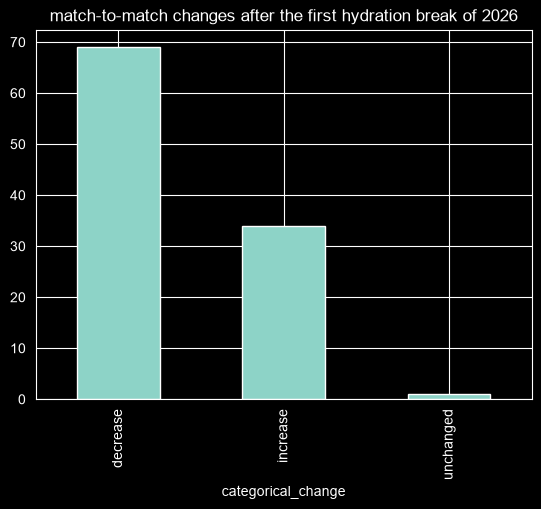

In [206]:
match_comp_first = pd.concat([
    match_by_match_id_12_22['total'].rename('total_12_22'),
    match_by_match_id_25_35['total'].rename('total_25_35')
], axis=1).assign(
    change_first=lambda x: x['total_25_35'] - x['total_12_22'],
    categorical_change=lambda x:np.select(
        [
            x['change_first']>0,x['change_first']<0
        ],['increase','decrease'],default='unchanged'
    )
)
match_comp_first['categorical_change'].value_counts().plot(kind='bar')
plt.title('match-to-match changes after the first hydration break of 2026')

In [207]:
match_comp_first['categorical_change'].value_counts()

categorical_change
decrease     69
increase     34
unchanged     1
Name: count, dtype: int64

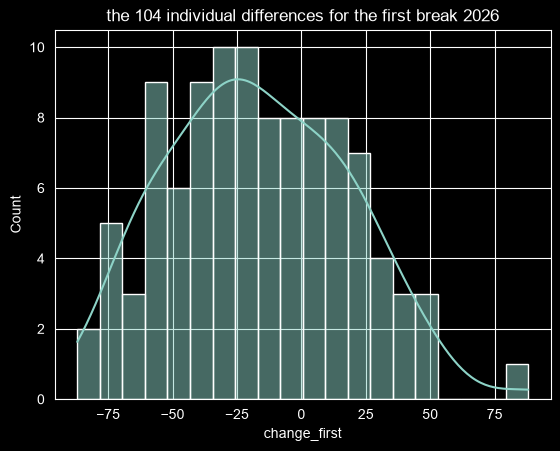

In [208]:
ax=sns.histplot(match_comp_first.change_first,kde=True,bins=20)
ax.set_title('the 104 individual differences for the first break 2026')
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\hydration break\\images\\histogram_first_break.png',dpi=300,bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'boxplot of 104 individual differences for the first break 2026')

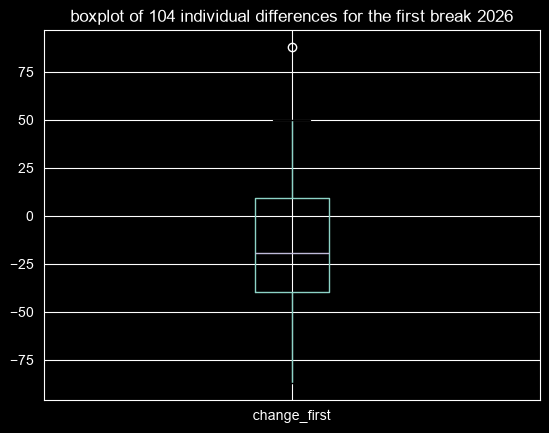

In [209]:
match_comp_first.boxplot(column='change_first')
plt.title('boxplot of 104 individual differences for the first break 2026')

In [210]:
match_comp_second = pd.concat([
    match_by_match_id_57_67['total'].rename('total_57_67'),
    match_by_match_id_70_80['total'].rename('total_70_80')
], axis=1).assign(
    change_second=lambda x: x['total_70_80'] - x['total_57_67'],
    categorical_change=lambda x:np.select(
        [
            x['change_second']>0,x['change_second']<0
        ],['increase','decrease'],default='unchanged'
    )
)
match_comp_second['categorical_change'].value_counts()

categorical_change
decrease     60
increase     42
unchanged     2
Name: count, dtype: int64

Text(0.5, 1.0, 'match-to-match changes after the second hydration break 2026')

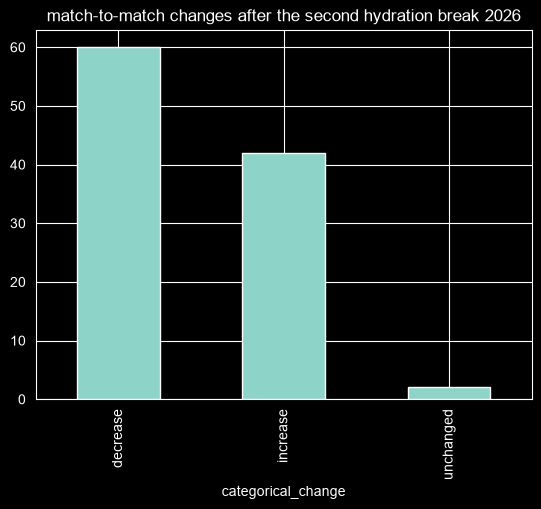

In [211]:
match_comp_second['categorical_change'].value_counts().plot(kind='bar')
plt.title('match-to-match changes after the second hydration break 2026')

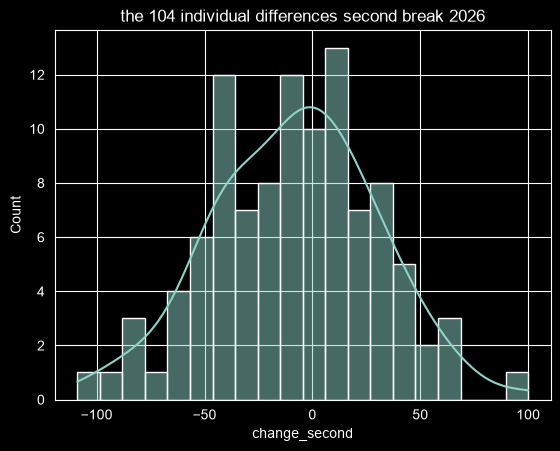

In [212]:
ax=sns.histplot(match_comp_second.change_second,kde=True,bins=20)
ax.set_title('the 104 individual differences second break 2026')
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\hydration break\\images\\histogram_second_break.png',dpi=300,bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'boxplot of 104 individual differences for the second break 2026')

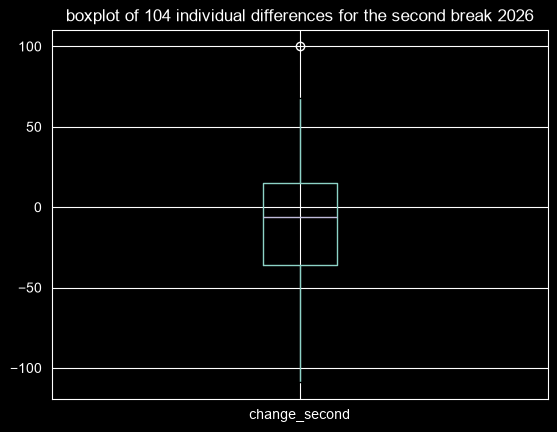

In [213]:
match_comp_second.boxplot(column='change_second')
plt.title('boxplot of 104 individual differences for the second break 2026')

In [214]:
(pd.concat([statistics(match_comp_first['change_first']).assign(window='first_break'),statistics(match_comp_second['change_second']).assign(window='second_break')])).melt(value_vars=['mean','median','standard deviation','maximum','minimum','25th quartile','75th quartile','IQR'],id_vars='window').pivot(index='variable',values='value',columns='window')

window,first_break,second_break
variable,,
25th quartile,-39.750000,-36.000000
75th quartile,9.500000,14.750000
IQR,49.250000,50.750000
maximum,88.000000,100.000000
mean,-16.807692,-8.288462
median,-19.500000,-6.000000
minimum,-87.000000,-109.000000
standard deviation,34.766929,38.016009


In [215]:
result_first_break=wilcoxon(
    match_comp_first['total_12_22'],
    match_comp_first['total_25_35'],alternative='two-sided',
    method='approx'
)
print('statistic:',result_first_break.statistic)
print('p-value:',result_first_break.pvalue)
print('z-statistic:',result_first_break.zstatistic)

statistic: 1317.0
p-value: 7.540640498541645e-06
z-statistic: -4.477827748888038


In [216]:
result_second_break=wilcoxon(
    match_comp_second['total_57_67'],
    match_comp_second['total_70_80'],alternative='two-sided',
    method='approx'
)
print('statistic:',result_second_break.statistic)
print('p-value:',result_second_break.pvalue)
print('z-statistic:',result_second_break.zstatistic)

statistic: 2003.0
p-value: 0.03738591851866471
z-statistic: -2.0815245595842353


In [217]:
n_first=len(match_comp_first)
r_first=np.abs(result_first_break.zstatistic)/np.sqrt(n_first)
print('first break')
print("N:",n_first)
print('r:',r_first)

first break
N: 104
r: 0.43908713596321847


In [218]:
n_second=len(match_comp_second)
r_second=np.abs(result_second_break.zstatistic)/np.sqrt(n_second)
print('second break')
print('N:',n_second)
print('r:',r_second)

second break
N: 104
r: 0.20411027591043546


In [219]:
alpha=0.05
number_of_tests=2
corrected_alpha=alpha/number_of_tests
corrected_alpha

0.025

In [220]:
match_comp_first.to_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\match_comp_first.csv')
match_comp_second.to_csv('C:\\Users\\dawit\\PycharmProjects\\hydration break\\data\\match_comp_second.csv')